# 01 — Build Jigsaw Cost Table

This notebook builds the canonical processed table for Jigsaw with:
- `n_yes`, `n_no`
- `delta_signed = log((n_yes+ε)/(n_no+ε))` (signed by majority)
- `abs_delta = |delta_signed|`
- `y_star ∈ {0,1}` (majority label; ties to positive configurable)

It also performs invariants/NA checks and writes `data/jigsaw_cost.csv`.


In [1]:
# Standard imports
import os, sys, json, math, datetime, subprocess, pathlib
from typing import Any, Dict

import numpy as np
import pandas as pd

# Plotting (only for quick sanity peeks here; full plots in 02_)
import matplotlib.pyplot as plt

# Ensure repo root is importable when running from notebooks/
REPO_ROOT = pathlib.Path.cwd().resolve().parent  # assuming notebooks/ is one level down
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Project imports
from data.jigsaw import build_jigsaw_frame  # your function


In [2]:
# Configuration parameters (surface eps, tie policy)
CFG = {
    "raw_csv": str(REPO_ROOT / "data" / "jigsaw" / "train.csv"),
    "out_csv": str(REPO_ROOT / "data" / "jigsaw_cost.csv"),
    "eps": 1.0,
    "tie_positive": True,
    "seed": 42,
}

np.random.seed(CFG["seed"])
print(json.dumps(CFG, indent=2))


{
  "raw_csv": "/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw/train.csv",
  "out_csv": "/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.csv",
  "eps": 1.0,
  "tie_positive": true,
  "seed": 42
}


In [3]:
def get_git_hash(default="unknown"):
    try:
        h = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT).decode().strip()
        return h
    except Exception:
        return default

RUN_META = {
    "timestamp_utc": datetime.datetime.utcnow().isoformat() + "Z",
    "git_hash": get_git_hash(),
    **CFG,
}
RUN_META


{'timestamp_utc': '2025-11-21T00:38:14.258423Z',
 'git_hash': 'cbeebc06de66766e19706f9db46d5d7d945b4f47',
 'raw_csv': '/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw/train.csv',
 'out_csv': '/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.csv',
 'eps': 1.0,
 'tie_positive': True,
 'seed': 42}

In [4]:
required = ["comment_text", "target", "toxicity_annotator_count"]
df_raw = pd.read_csv(CFG["raw_csv"], usecols=required, low_memory=False)

missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns in raw CSV: {missing}")

print(f"Loaded raw: {len(df_raw):,} rows")
df_raw.head(3)


Loaded raw: 1,804,874 rows


,target,comment_text,toxicity_annotator_count
0,0.0,"This is so cool. It's like, 'would you want yo...",4
1,0.0,Thank you!! This would make my life a lot less...,4
2,0.0,This is such an urgent design problem; kudos t...,4


In [5]:
jf = build_jigsaw_frame(df_raw, eps=CFG["eps"], tie_positive=CFG["tie_positive"]).reset_index(drop=True)
print(f"Processed rows (after drops/cleaning): {len(jf):,}")
jf.head(5)

Processed rows (after drops/cleaning): 1,804,871


,comment_text,n_yes,n_no,delta_signed,abs_delta,y_star
0,"This is so cool. It's like, 'would you want yo...",0,4,-1.609438,1.609438,0
1,Thank you!! This would make my life a lot less...,0,4,-1.609438,1.609438,0
2,This is such an urgent design problem; kudos t...,0,4,-1.609438,1.609438,0
3,Is this something I'll be able to install on m...,0,4,-1.609438,1.609438,0
4,haha you guys are a bunch of losers.,42,5,1.969441,1.969441,1


In [6]:
# No NA leakage in required processed columns
must_have = ["comment_text", "n_yes", "n_no", "delta_signed", "abs_delta", "y_star"]
na_counts = jf[must_have].isna().sum()
# --- quick diagnostics before invariants ---
must_have = ["comment_text", "n_yes", "n_no", "delta_signed", "abs_delta", "y_star"]
print("NA counts in required columns:")
print(jf[must_have].isna().sum(), "\n")

print("Rows with zero annotators (n_yes + n_no == 0):")
print(jf[(jf["n_yes"] + jf["n_no"]) == 0].head(), "\n")

bad_yes = jf[pd.to_numeric(jf["n_yes"], errors="coerce").isna()]
bad_no  = jf[pd.to_numeric(jf["n_no"],  errors="coerce").isna()]
print("Non-numeric n_yes/n_no counts:", len(bad_yes), len(bad_no))
assert (na_counts == 0).all(), f"NA leakage detected:\n{na_counts}"

# Counts consistent: n_yes + n_no > 0 and integers
assert ((jf["n_yes"] + jf["n_no"]) > 0).all(), "Found rows with zero annotators after processing."

# Dtypes
jf["n_yes"] = jf["n_yes"].astype("int32")
jf["n_no"]  = jf["n_no"].astype("int32")
jf["y_star"] = jf["y_star"].astype("int8")
jf["delta_signed"] = jf["delta_signed"].astype("float32")
jf["abs_delta"] = jf["abs_delta"].astype("float32")

# Logical ties: where n_yes == n_no, y_star should equal tie policy (1 if tie_positive else 0)
tie_mask = jf["n_yes"] == jf["n_no"]
if tie_mask.any():
    expected = 1 if CFG["tie_positive"] else 0
    assert (jf.loc[tie_mask, "y_star"] == expected).all(), "Tie-handling mismatch with tie_positive policy."

# Basic range sanity
assert ((jf["abs_delta"] >= 0).all()), "|Δ| should be non-negative."

print("All invariants passed, dtypes set.")
jf.dtypes


NA counts in required columns:
comment_text    0
n_yes           0
n_no            0
delta_signed    0
abs_delta       0
y_star          0
dtype: int64 

Rows with zero annotators (n_yes + n_no == 0):
Empty DataFrame
Columns: [comment_text, n_yes, n_no, delta_signed, abs_delta, y_star]
Index: [] 

Non-numeric n_yes/n_no counts: 0 0
All invariants passed, dtypes set.


comment_text    string[python]
n_yes                    int32
n_no                     int32
delta_signed           float32
abs_delta              float32
y_star                    int8
dtype: object

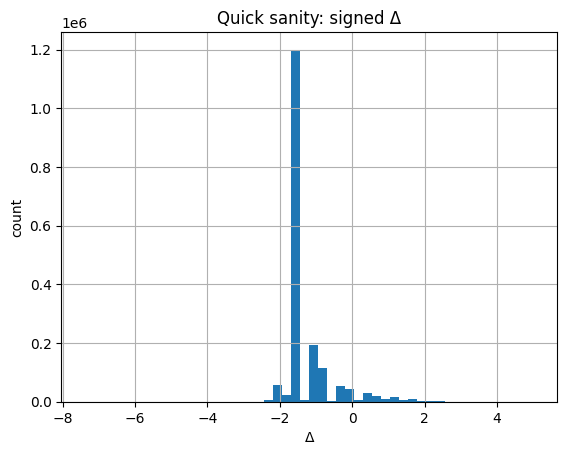

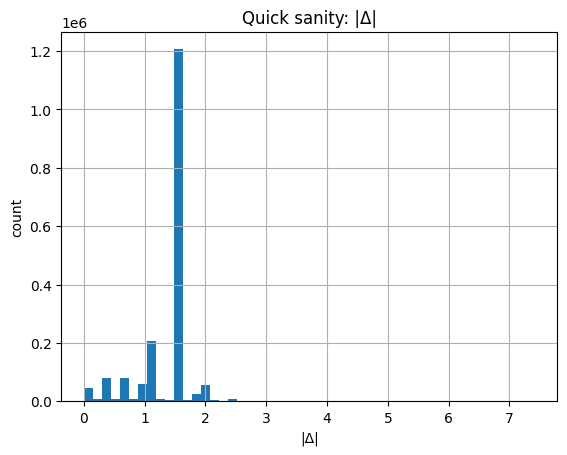

In [7]:
ax = jf["delta_signed"].hist(bins=50)
ax.set_title("Quick sanity: signed Δ"); ax.set_xlabel("Δ"); ax.set_ylabel("count")
plt.show()

ax = jf["abs_delta"].hist(bins=50)
ax.set_title("Quick sanity: |Δ|"); ax.set_xlabel("|Δ|"); ax.set_ylabel("count")
plt.show()


In [8]:
out_path = pathlib.Path(CFG["out_csv"])
out_path.parent.mkdir(parents=True, exist_ok=True)
jf.to_csv(out_path, index=False)
print(f"[✓] Wrote {out_path} ({len(jf):,} rows)")

meta_path = out_path.with_suffix(".meta.json")
with open(meta_path, "w") as f:
    json.dump(RUN_META | {"n_rows": int(len(jf))}, f, indent=2)
print(f"[✓] Wrote {meta_path}")


[✓] Wrote /storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.csv (1,804,871 rows)
[✓] Wrote /storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.meta.json


### Sample processed rows

In [9]:
jf.sample(5, random_state=CFG["seed"])

,comment_text,n_yes,n_no,delta_signed,abs_delta,y_star
1345987,Knee-jerk reaction is all he knows.,6,38,-1.717651,1.717651,0
1165665,The DPRK will never bite the PRC hand that fee...,3,7,-0.693147,0.693147,0
102806,Why did you find it necessary to spend much o...,0,4,-1.609438,1.609438,0
1258569,"There are suicides on the subway, and from tal...",0,4,-1.609438,1.609438,0
1421255,Looks like there are about 6 people including ...,5,5,0.000000,0.000000,1


In [10]:
# === Final validation: invariants + quick sanity prints ===
import json, pathlib as pl, numpy as np, pandas as pd

CSV = "/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.csv"
META = CSV.replace(".csv", ".meta.json")

df = pd.read_csv(CSV)
must = ["comment_text","n_yes","n_no","delta_signed","abs_delta","y_star"]
na = df[must].isna().sum()
print("NA counts:\n", na)

assert (na == 0).all(), f"NA leakage:\n{na}"
assert ((df["n_yes"] + df["n_no"]) > 0).all(), "Found rows with zero annotators."
assert (df["y_star"].equals((df["delta_signed"] >= 0).astype(int))), "y* != 1[Δ≥0]"
assert np.allclose(df["abs_delta"].to_numpy(), np.abs(df["delta_signed"].to_numpy()), atol=1e-6)

print("Mean|Δ| =", df["abs_delta"].mean(), " Max|Δ| =", df["abs_delta"].max(), "  y*=1 frac =", df["y_star"].mean())

# meta echo
try:
    print("\nMeta JSON:\n", json.dumps(json.loads(pl.Path(META).read_text()), indent=2)[:1500], " ...")
except FileNotFoundError:
    print("Meta file missing:", META)

print("✓ Final validation passed.")


NA counts:
 comment_text    0
n_yes           0
n_no            0
delta_signed    0
abs_delta       0
y_star          0
dtype: int64
Mean|Δ| = 1.3967443578302077  Max|Δ| = 7.415175   y*=1 frac = 0.0799691501497891

Meta JSON:
 {
  "timestamp_utc": "2025-11-21T00:38:14.258423Z",
  "git_hash": "cbeebc06de66766e19706f9db46d5d7d945b4f47",
  "raw_csv": "/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw/train.csv",
  "out_csv": "/storage/project/r-smussmann3-0/kkang68/projects/cost-sensitive-learning/data/jigsaw_cost.csv",
  "eps": 1.0,
  "tie_positive": true,
  "seed": 42,
  "n_rows": 1804871
}  ...
✓ Final validation passed.
